# PA3: exploração e preparação

Este notebook (1) explora o catálogo bruto, (2) define regras de preparação justificadas e (3) grava `data/processed/filmes_preparados.csv`, reconciliando as contagens com o CSV bruto. O arquivo bruto permanece intacto.

In [1]:
from pathlib import Path
import sys

def localizar_raiz(inicio=None):
    """Sobe a partir do diretório atual até achar data/raw/imdb_top_1000.csv."""
    inicio = Path(inicio or Path.cwd()).resolve()
    for pasta in [inicio, *inicio.parents]:
        if (pasta / "data" / "raw" / "imdb_top_1000.csv").is_file():
            return pasta
    raise FileNotFoundError("data/raw/imdb_top_1000.csv não encontrado acima de "
                            f"{inicio}. Consulte data/README.md para obter o CSV.")

ROOT = localizar_raiz()
sys.path.insert(0, str(ROOT / "src"))
CSV_BRUTO = ROOT / "data" / "raw" / "imdb_top_1000.csv"
print("Raiz do projeto localizada; CSV bruto:", CSV_BRUTO.relative_to(ROOT))

Raiz do projeto localizada; CSV bruto: data\raw\imdb_top_1000.csv


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from preparo import preparar_catalogo

pd.set_option("display.width", 140)
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
MET = ROOT / "reports" / "metrics"; MET.mkdir(parents=True, exist_ok=True)
PROC = ROOT / "data" / "processed"; PROC.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
COR = "#2F5D8A"

bruto = pd.read_csv(CSV_BRUTO)
print("Linhas x colunas:", bruto.shape)

Linhas x colunas: (1000, 16)


## 1. Perfil do bruto

### 1.1 Valores ausentes
Nulos vêm do CSV como campo vazio. Eles são **ausência de informação**, não zero.

             nulos     %
Certificate    101  10.1
Meta_score     157  15.7
Gross          169  16.9


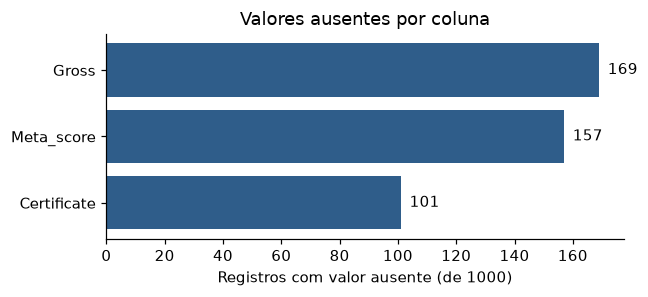

In [3]:
nulos = bruto.isna().sum()
tab_nulos = pd.DataFrame({"nulos": nulos, "%": (100 * nulos / len(bruto)).round(1)})
print(tab_nulos[tab_nulos["nulos"] > 0])

ordem = nulos[nulos > 0].sort_values()
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.barh(ordem.index, ordem.values, color=COR)
for y, v in enumerate(ordem.values):
    ax.text(v + 3, y, str(v), va="center")
ax.set_xlabel("Registros com valor ausente (de 1000)"); ax.set_title("Valores ausentes por coluna")
fig.tight_layout(); fig.savefig(FIG / "nulos_por_coluna.png"); plt.show()
## RA: 10356420 - KAYO OLIVEIRA NUKUI ##

### 1.2 Tipos e formatos problemáticos
`Released_Year`, `Runtime` e `Gross` são texto no CSV. Verificação de cada formato:

In [4]:
ano_num = pd.to_numeric(bruto["Released_Year"], errors="coerce")
print("Released_Year não numérico:", int(ano_num.isna().sum()))
print(bruto.loc[ano_num.isna(), ["Series_Title", "Released_Year", "Certificate", "Runtime"]].to_string())
print()
print("Runtime no formato 'N min':", int(bruto["Runtime"].str.match(r"^\d+ min$").sum()), "de", len(bruto))
gross_ok = bruto["Gross"].dropna().str.match(r"^\d{1,3}(,\d{3})*$")
print("Gross preenchido:", int(bruto["Gross"].notna().sum()), "| no formato com vírgulas de milhar:", int(gross_ok.sum()))
print("Exemplos de Gross:", bruto["Gross"].dropna().head(3).tolist())

Released_Year não numérico: 1
    Series_Title Released_Year Certificate  Runtime
966    Apollo 13            PG           U  140 min

Runtime no formato 'N min': 1000 de 1000
Gross preenchido: 831 | no formato com vírgulas de milhar: 831
Exemplos de Gross: ['28,341,469', '134,966,411', '534,858,444']


O valor `PG` em `Released_Year` é uma classificação indicativa que caiu na coluna errada (linha de *Apollo 13*). A regra adotada é não inventar o ano: o campo vira ausente. Isso não afeta o recomendador, que não usa o ano como atributo, apenas como critério de desempate.

### 1.3 Duplicatas

In [5]:
print("Linhas totalmente duplicadas:", int(bruto.duplicated().sum()))
print("Títulos distintos:", bruto["Series_Title"].nunique())
print("Sinopses repetidas:", int(bruto["Overview"].duplicated().sum()))
bruto.loc[bruto["Series_Title"].duplicated(keep=False), ["Series_Title", "Released_Year", "Director", "Star1", "Overview"]]

Linhas totalmente duplicadas: 0
Títulos distintos: 999
Sinopses repetidas: 0


,Series_Title,Released_Year,Director,Star1,Overview
87,Drishyam,2013,Jeethu Joseph,Mohanlal,A man goes to extreme lengths to save his fami...
136,Drishyam,2015,Nishikant Kamat,Ajay Devgn,Desperate measures are taken by a man who trie...


*Drishyam* (2013) e *Drishyam* (2015) têm anos, diretores e sinopses diferentes: são filmes distintos com o mesmo título. Nenhuma linha é removida; consultas e métricas usam `film_id`.

### 1.4 Gêneros (multirrótulo)
`Genre` traz de 1 a 3 gêneros separados por vírgula.

Gêneros por filme: {1: 105, 2: 249, 3: 646}
Gêneros distintos: 21
Genre
Drama        724
Comedy       233
Crime        209
Adventure    196
Action       189
Thriller     137
Romance      125
Biography    109
Mystery       99
Animation     82
Sci-Fi        67
Fantasy       66
History       56
Family        56
War           51
Music         35
Horror        32
Western       20
Film-Noir     19
Sport         19
Musical       17


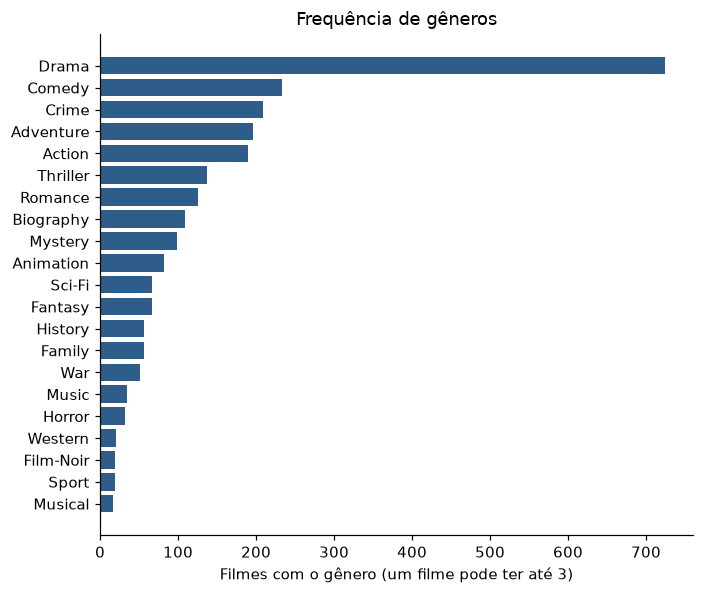

In [6]:
generos = bruto["Genre"].str.split(", ")
print("Gêneros por filme:", generos.str.len().value_counts().sort_index().to_dict())
freq = generos.explode().value_counts()
print("Gêneros distintos:", freq.size)
print(freq.to_string())

top = freq.sort_values()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.barh(top.index, top.values, color=COR)
ax.set_xlabel("Filmes com o gênero (um filme pode ter até 3)"); ax.set_title("Frequência de gêneros")
fig.tight_layout(); fig.savefig(FIG / "generos_frequencia.png"); plt.show()

Drama aparece em 72,4% dos filmes. Isso importa para a avaliação: sob qualquer método, é fácil dois filmes compartilharem "Drama". A etapa de avaliação do notebook 03 trata esse ponto com uma linha de base aleatória.

### 1.5 Ano de lançamento, nota e votos

Ano: mín 1920 | mediana 1999 | máx 2020 | n = 999
count    1000.00
mean        7.95
std         0.28
min         7.60
25%         7.70
50%         7.90
75%         8.10
max         9.30
count       1000.0
mean      273693.0
std       327373.0
min        25088.0
25%        55526.0
50%       138548.0
75%       374161.0
max      2343110.0


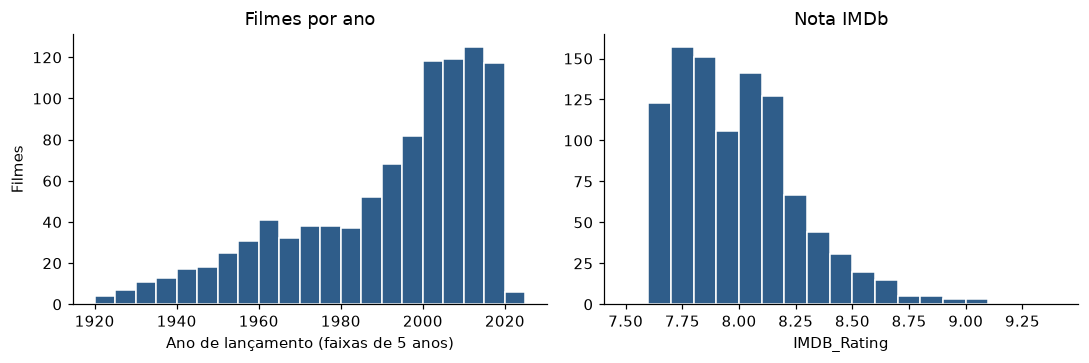

In [7]:
ano = ano_num.dropna().astype(int)
print("Ano: mín", ano.min(), "| mediana", int(ano.median()), "| máx", ano.max(), "| n =", len(ano))
print(bruto["IMDB_Rating"].describe().round(2).to_string())
print(bruto["No_of_Votes"].describe().round(0).to_string())

fig, axs = plt.subplots(1, 2, figsize=(10, 3.4))
axs[0].hist(ano, bins=range(1920, 2030, 5), color=COR, edgecolor="white")
axs[0].set_xlabel("Ano de lançamento (faixas de 5 anos)"); axs[0].set_ylabel("Filmes"); axs[0].set_title("Filmes por ano")
axs[1].hist(bruto["IMDB_Rating"], bins=np.arange(7.5, 9.4, 0.1), color=COR, edgecolor="white")
## RA: 10356420 - KAYO OLIVEIRA NUKUI ##
axs[1].set_xlabel("IMDB_Rating"); axs[1].set_title("Nota IMDb")
fig.tight_layout(); fig.savefig(FIG / "ano_e_nota.png"); plt.show()

A nota mínima é 7,6: a base é um recorte de filmes bem avaliados, não uma amostra do universo de filmes. Isso limita qualquer generalização.

### 1.6 Tamanho das sinopses

       caracteres  palavras
count      1000.0    1000.0
mean        146.3      25.0
std          43.7       7.8
min          40.0       8.0
25%         114.0      19.0
50%         142.0      24.0
75%         172.0      30.0
max         313.0      56.0


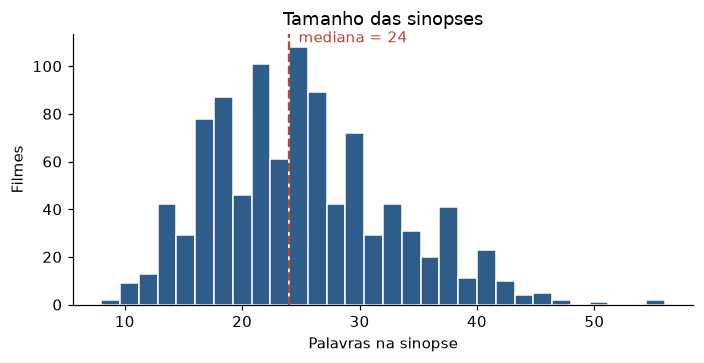

In [8]:
n_char = bruto["Overview"].str.len(); n_pal = bruto["Overview"].str.split().str.len()
print(pd.DataFrame({"caracteres": n_char.describe(), "palavras": n_pal.describe()}).round(1))

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(n_pal, bins=30, color=COR, edgecolor="white")
ax.axvline(n_pal.median(), color="#B5472F", ls="--"); ax.text(n_pal.median() + 0.8, ax.get_ylim()[1] * 0.97, f"mediana = {n_pal.median():.0f}", color="#B5472F", bbox=dict(facecolor="white", edgecolor="none", pad=1))
ax.set_xlabel("Palavras na sinopse"); ax.set_ylabel("Filmes"); ax.set_title("Tamanho das sinopses")
fig.tight_layout(); fig.savefig(FIG / "overview_tamanho.png"); plt.show()

Sinopses curtas (mediana de cerca de 24 palavras) dão pouco vocabulário ao TF-IDF. Essa é uma limitação esperada para o modelo do notebook 03.

## 2. Regras de preparação

| Regra | O que faz | Justificativa |
|---|---|---|
| R0 | Não modificar `data/raw/` | Dados brutos são imutáveis; o processado é uma cópia derivada. |
| R1 | `film_id` = posição da linha no bruto | Títulos não são únicos (*Drishyam*). |
| R2 | Remover espaços nas pontas e colapsar espaços internos em textos | Evita tokens e chaves divergentes; não muda o conteúdo. |
| R3 | `Released_Year` não numérico vira ausente | Não inserir ano a partir de fonte externa não registrada. |
| R4 | `Runtime` "142 min" para inteiro `Runtime_min` | Tipo numérico utilizável. |
| R5 | `Gross` com vírgulas para inteiro `Gross_usd`; ausente continua ausente | Ausência não é zero; zerar distorceria estatísticas. |
| R6 | `Certificate` e `Meta_score` ausentes continuam ausentes | Sem preenchimento: nenhum modelo da etapa 2 os usa. |
| R7 | Acrescentar `Overview_chars` e `Overview_words` | Medidas descritivas da sinopse. |
| R8 | Nenhuma linha removida | Sem duplicatas exatas; homônimos são filmes distintos; sinopses todas preenchidas. |
| R9 | Descartar `Poster_Link` do processado | Não é atributo do modelo; continua no bruto. |

A sinopse **não** é lematizada nem teve stop words removidas aqui: isso é feito dentro do vetorizador, no notebook 03, para manter o texto original legível.

In [9]:
prep = preparar_catalogo(bruto)
prep.to_csv(PROC / "filmes_preparados.csv", index=False)
print("Gravado:", (PROC / "filmes_preparados.csv").relative_to(ROOT))
prep.dtypes.astype(str).to_frame("tipo").T

Gravado: data\processed\filmes_preparados.csv


,film_id,Series_Title,Released_Year,Certificate,Runtime_min,Genre,IMDB_Rating,Meta_score,No_of_Votes,Gross_usd,Director,Star1,Star2,Star3,Star4,Overview,Overview_chars,Overview_words
tipo,int64,string,Int64,string,Int64,string,float64,Float64,int64,Int64,string,string,string,string,string,string,Int64,Int64


## 3. Reconciliação antes e depois

Cada contagem do processado é comparada ao bruto, relendo o arquivo gravado do disco.

In [10]:
proc = pd.read_csv(PROC / "filmes_preparados.csv")
bruto2 = pd.read_csv(CSV_BRUTO)  # releitura independente do bruto

ano_ok = pd.to_numeric(bruto2["Released_Year"], errors="coerce")
linhas = [
    ("Linhas", len(bruto2), len(proc)),
    ("Colunas (esperado: 16 - 3 [Poster_Link, Runtime, Gross] + 5 [film_id, Runtime_min, Gross_usd, Overview_chars, Overview_words])", bruto2.shape[1] - 3 + 5, proc.shape[1]),
    ("Títulos distintos", bruto2["Series_Title"].nunique(), proc["Series_Title"].nunique()),
    ("Ausentes em Certificate", bruto2["Certificate"].isna().sum(), proc["Certificate"].isna().sum()),
    ("Ausentes em Meta_score", bruto2["Meta_score"].isna().sum(), proc["Meta_score"].isna().sum()),
    ("Ausentes em Gross (bruto) / Gross_usd (processado)", bruto2["Gross"].isna().sum(), proc["Gross_usd"].isna().sum()),
    ("Ausentes em Released_Year (bruto: não numéricos)", ano_ok.isna().sum(), proc["Released_Year"].isna().sum()),
    ("Ausentes em Overview", bruto2["Overview"].isna().sum(), proc["Overview"].isna().sum()),
    ("Zeros criados em Gross_usd", 0, int((proc["Gross_usd"] == 0).sum())),
    ("Soma de No_of_Votes", bruto2["No_of_Votes"].sum(), proc["No_of_Votes"].sum()),
]
recon = pd.DataFrame(linhas, columns=["verificação", "bruto", "processado"]).astype({"bruto": int, "processado": int})
recon["confere"] = recon["bruto"] == recon["processado"]
print(recon.to_string(index=False))
assert recon["confere"].all(), "Reconciliação falhou"

# Colunas que mudam de representação: conferência valor a valor
g = bruto2["Gross"].dropna().str.replace(",", "").astype(int)
assert (proc.loc[bruto2["Gross"].notna(), "Gross_usd"].to_numpy() == g.to_numpy()).all()
assert (proc["Runtime_min"].to_numpy() == bruto2["Runtime"].str.extract(r"(\d+)")[0].astype(int).to_numpy()).all()
assert (proc["Series_Title"] == bruto2["Series_Title"]).all() and (proc["Genre"] == bruto2["Genre"]).all()
print("Conferência valor a valor de Gross, Runtime, título e gênero: OK")
print("Apollo 13 no processado ->", proc.loc[proc["Series_Title"] == "Apollo 13", ["film_id", "Released_Year", "Certificate"]].to_dict("records"))

                                                                                                                   verificação     bruto  processado  confere
                                                                                                                        Linhas      1000        1000     True
Colunas (esperado: 16 - 3 [Poster_Link, Runtime, Gross] + 5 [film_id, Runtime_min, Gross_usd, Overview_chars, Overview_words])        18          18     True
                                                                                                             Títulos distintos       999         999     True
                                                                                                       Ausentes em Certificate       101         101     True
                                                                                                        Ausentes em Meta_score       157         157     True
                                                    

In [11]:
perfil = {
    "fonte": "data/raw/imdb_top_1000.csv (Kaggle, Harshit Shankhdhar)",
    "linhas_bruto": int(len(bruto2)), "colunas_bruto": int(bruto2.shape[1]),
    "linhas_processado": int(len(proc)), "colunas_processado": int(proc.shape[1]),
    "titulos_distintos": int(bruto2["Series_Title"].nunique()),
    "linhas_duplicadas_exatas": int(bruto2.duplicated().sum()),
    "ausentes_bruto": {c: int(n) for c, n in bruto2.isna().sum().items() if n},
    "released_year_nao_numerico": int(ano_ok.isna().sum()),
    "generos_distintos": int(freq.size),
    "overview_palavras_mediana": float(n_pal.median()), "overview_palavras_media": round(float(n_pal.mean()), 2),
    "overview_palavras_min": int(n_pal.min()), "overview_palavras_max": int(n_pal.max()),
}
(MET / "perfil_base.json").write_text(json.dumps(perfil, ensure_ascii=False, indent=2), encoding="utf-8")
recon.to_csv(MET / "reconciliacao_preparo.csv", index=False)
print(json.dumps(perfil, ensure_ascii=False, indent=2))

{
  "fonte": "data/raw/imdb_top_1000.csv (Kaggle, Harshit Shankhdhar)",
  "linhas_bruto": 1000,
  "colunas_bruto": 16,
  "linhas_processado": 1000,
  "colunas_processado": 18,
  "titulos_distintos": 999,
  "linhas_duplicadas_exatas": 0,
  "ausentes_bruto": {
    "Certificate": 101,
    "Meta_score": 157,
    "Gross": 169
  },
  "released_year_nao_numerico": 1,
  "generos_distintos": 21,
  "overview_palavras_mediana": 24.0,
  "overview_palavras_media": 25.0,
  "overview_palavras_min": 8,
  "overview_palavras_max": 56
}


## 4. Conclusões e limites

- Preparação sem perda de registros: 1000 linhas no bruto e 1000 no processado; ausências preservadas e reconciliadas.
- O único tratamento com perda de informação aparente é `Released_Year` de *Apollo 13* (de "PG" para ausente), porque o valor bruto não era um ano.
- Este notebook descreve a base; não mostra que as sinopses ou os gêneros do catálogo sejam fiéis a uma fonte externa.
- O catálogo é um recorte de filmes bem avaliados, com sinopses curtas; resultados do notebook 03 valem para este catálogo.